Code to test the performance of shifting the data to account for misclassification errors from diffusion time in the testing environment.

TODO: 

In [1]:
from pathlib import Path

ROOT_DIR = Path.cwd().parent
DATA_DIR = ROOT_DIR.joinpath('data')
ONNX_MODEL_DIR = ROOT_DIR.joinpath('onnx_models')
INDICES_DIR = ROOT_DIR.joinpath("saved_indices")

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

Load up data as dataframe, and create the classification target column (ground truth methane > 0 ppm)

In [2]:
df = pd.read_fwf(DATA_DIR.joinpath("ethylene_methane.txt"), skiprows=1, header=None, names=["Time", "Methane ppm", "Ethylene ppm", "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8", "S9", "S10", "S11", "S12", "S13", "S14", "S15", "S16"])
df.insert(1, "Target", df["Methane ppm"] > 0)

In [3]:
print("Number of True targets:", len(df[df['Target'].isin([True])]))
print("Number of False targets:", len(df[df['Target'].isin([False])]))

Number of True targets: 1849752
Number of False targets: 2328752


In [4]:
shifts = range(15, 25, 1)
for i in shifts:
    df.insert(1, f"Target_shifted_{i}", df["Target"].shift(i*100))

In [14]:
xgbmodels = []
skmodels = []
tfmodels = []
import xgboost as xgb
spw = len(df[df['Target'].isin([False])]) / len(df[df['Target'].isin([True])])
xgbm = xgb.XGBClassifier(
    n_estimators=3000, max_depth=3, learning_rate=0.01,
    scale_pos_weight=spw, tree_method="hist",
    subsample=0.5, colsample_bytree=0.5, min_child_weight=100,
    gamma=2.0, reg_alpha=0.5, reg_lambda=10.0,
    objective="binary:logistic", eval_metric="logloss",
    early_stopping_rounds=50, random_state=42,
    n_jobs=-1, verbosity=0,
)
xgbmodels.append(xgbm)
from sklearn.linear_model import LogisticRegression
log = LogisticRegression()
#skmodels.append(log)
from sklearn.svm import LinearSVC
lsvc = LinearSVC()
skmodels.append(lsvc)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
rforest = RandomForestClassifier()
gboost = GradientBoostingClassifier()
skmodels.append(rforest)
skmodels.append(gboost)
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier()
skmodels.append(mlp)



In [ ]:
import tensorflow as tf
import keras

def build_cnn():
    inp = keras.Input(shape=(WINDOW_LEN, N_SENSORS))
    x = keras.layers.Conv1D(32, 3, padding="same", use_bias=False)(inp)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation("relu")(x)
    x = keras.layers.Conv1D(64, 7, strides=2, padding="same", use_bias=False)(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation("relu")(x)
    x = keras.layers.Conv1D(64, 5, padding="same", use_bias=False)(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation("relu")(x)
    se = keras.layers.GlobalAveragePooling1D()(x)
    se = keras.layers.Dense(16, activation="relu")(se)
    se = keras.layers.Dense(64, activation="sigmoid")(se)
    se = keras.layers.Reshape((1, 64))(se)
    x = keras.layers.Multiply()([x, se])
    x = keras.layers.GlobalAveragePooling1D()(x)
    x = keras.layers.Dropout(0.3)(x)
    out = keras.layers.Dense(1, activation="sigmoid")(x)
    return keras.Model(inp, out)

tf.random.set_seed(42); np.random.seed(42)

cnn = build_cnn()
cnn.compile(optimizer=keras.optimizers.Adam(learning_rate=3e-4),
                loss="relu", metrics=["accuracy"])

cbs = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=10,
            restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
            patience=3, min_lr=1e-6)]

tfmodels.append(cnn)

NameError: name 'WINDOW_LEN' is not defined

Test the accuracy score of every model we included earlier for each target timeshift

In [17]:
from sklearn.metrics import accuracy_score
accuracy_scores = []
split = [.7, .15, .15]

for i in shifts:
    shifted = df[[f"Target_shifted_{i}", "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8", "S9", "S10", "S11", "S12", "S13", "S14", "S15", "S16"]].to_numpy()
    shifted = np.delete(shifted, np.s_[0:i*100], axis=0)
    length = len(shifted)
    print(type(shifted[0,0]))

    train_end = int(length * split[0])
    test_end = int(train_end + length * split[1])

    xtrain = shifted[:train_end, 1:]
    ytrain = shifted[:train_end, 0]
    xtest = shifted[train_end:test_end, 1:]
    ytest = shifted[train_end:test_end, 0]
    xval = shifted[test_end:length, 1:]
    yval = shifted[test_end:length, 0]

    accuracy_dict = {}

    for model in xgbmodels:
        model.fit(xtrain, ytrain, eval_set=[(xtrain, ytrain), (xtest, ytest)])
        ypred = model.predict(xval)
        accuracy = accuracy_score(list(map(int,yval)), ypred)
        accuracy_dict[type(model).__name__] = accuracy
    for model in skmodels:
        model.fit(xtrain, ytrain.astype('bool'))
        ypred = model.predict(xval)
        accuracy = accuracy_score(list(map(int,yval)), ypred)
        accuracy_dict[type(model).__name__] = accuracy
    for model in tfmodels:
        pass
    print(f"Dataset shifted by {i}s processed.")
    accuracy_scores.append(accuracy_dict)
    

<class 'bool'>
[0]	validation_0-logloss:0.68898	validation_1-logloss:0.69275
[1]	validation_0-logloss:0.68007	validation_1-logloss:0.68354
[2]	validation_0-logloss:0.67133	validation_1-logloss:0.67450
[3]	validation_0-logloss:0.66282	validation_1-logloss:0.66557
[4]	validation_0-logloss:0.65442	validation_1-logloss:0.65682
[5]	validation_0-logloss:0.64618	validation_1-logloss:0.64823
[6]	validation_0-logloss:0.63814	validation_1-logloss:0.63986
[7]	validation_0-logloss:0.63032	validation_1-logloss:0.63169
[8]	validation_0-logloss:0.62253	validation_1-logloss:0.62361
[9]	validation_0-logloss:0.61489	validation_1-logloss:0.61571
[10]	validation_0-logloss:0.60740	validation_1-logloss:0.60796
[11]	validation_0-logloss:0.60007	validation_1-logloss:0.60043
[12]	validation_0-logloss:0.59284	validation_1-logloss:0.59290
[13]	validation_0-logloss:0.58575	validation_1-logloss:0.58551
[14]	validation_0-logloss:0.57881	validation_1-logloss:0.57826
[15]	validation_0-logloss:0.57196	validation_1-log

Run this cell to include base case

In [ ]:

shifts = list(shifts)
shifts.insert(0,0)
data = df[[f"Target", "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8", "S9", "S10", "S11", "S12", "S13", "S14", "S15", "S16"]].to_numpy()

xtrain = data[:train_end, 1:]
ytrain = data[:train_end, 0]
xtest = data[train_end:test_end, 1:]
ytest = data[train_end:test_end, 0]
xval = data[test_end:length, 1:]
yval = data[test_end:length, 0]

accuracy_dict = {}

for model in xgbmodels:
    model.fit(xtrain, ytrain, eval_set=[(xtrain, ytrain), (xtest, ytest)])
    ypred = model.predict(xval)
    accuracy = accuracy_score(list(map(int,yval)), ypred)
    accuracy_dict[type(model).__name__] = accuracy
for model in skmodels:
    model.fit(xtrain, ytrain.astype('bool'))
    ypred = model.predict(xval)
    accuracy = accuracy_score(list(map(int,yval)), ypred)
    accuracy_dict[type(model).__name__] = accuracy
for model in tfmodels:
    pass
print("Base case dataset processed.")
accuracy_scores.insert(0,accuracy_dict)

[0]	validation_0-logloss:0.69092	validation_1-logloss:0.69419
[1]	validation_0-logloss:0.68386	validation_1-logloss:0.68649
[2]	validation_0-logloss:0.67694	validation_1-logloss:0.67893
[3]	validation_0-logloss:0.67022	validation_1-logloss:0.67165
[4]	validation_0-logloss:0.66369	validation_1-logloss:0.66432
[5]	validation_0-logloss:0.65721	validation_1-logloss:0.65720
[6]	validation_0-logloss:0.65080	validation_1-logloss:0.65019
[7]	validation_0-logloss:0.64466	validation_1-logloss:0.64349
[8]	validation_0-logloss:0.63851	validation_1-logloss:0.63673
[9]	validation_0-logloss:0.63252	validation_1-logloss:0.63013
[10]	validation_0-logloss:0.62665	validation_1-logloss:0.62374
[11]	validation_0-logloss:0.62089	validation_1-logloss:0.61745
[12]	validation_0-logloss:0.61517	validation_1-logloss:0.61119
[13]	validation_0-logloss:0.60957	validation_1-logloss:0.60504
[14]	validation_0-logloss:0.60406	validation_1-logloss:0.59900
[15]	validation_0-logloss:0.59871	validation_1-logloss:0.59306
[1

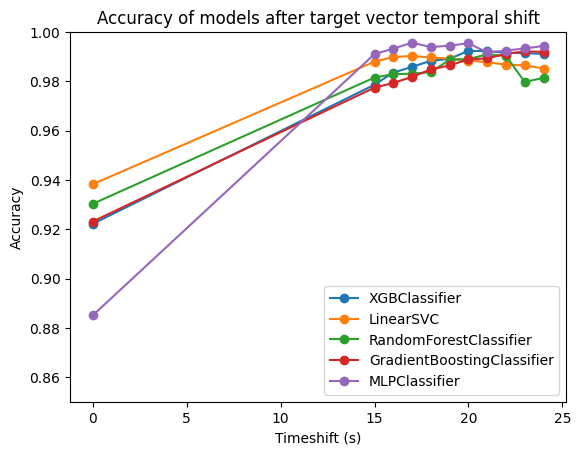

In [36]:
models = xgbmodels + skmodels #+ tfmodels
for model in models:
    axis = []
    for i in range(len(accuracy_scores)):
        axis.append(accuracy_scores[i][type(model).__name__])
    plt.plot(shifts, axis, label=type(model).__name__, marker="o")
plt.title("Accuracy of models after target vector temporal shift")
plt.legend()
plt.xlabel("Timeshift (s)")
plt.ylabel("Accuracy")
plt.ylim(0.85,1.0)
plt.show()
